# Waveform PCA scree and PC-space clustering

Castellucci et al. (*Cell Reports* 2025) Figure 1D–E style, on the **insula concat-NMF** waveform matrix.

Compute (Slurm, tables only):

```bash
sbatch scripts/slurm/nmf_pc_clustering.sh
```

This notebook **only reads** `results/nmf/pc_*.csv` / `rank_selection_metrics.csv` and writes SVGs under `img/nmf/`.
It does not refit NMF and does not overwrite `channel_assignments.csv`.

- **1D / 1E:** their rank-selection rule in PC space (scree; silhouette and Calinski–Harabasz vs *k*).
- **NMF rank:** cophenetic, bootstrap ARI, cosine silhouette, and reconstruction error vs *k* — this is the justification for canonical *k*=3.
- **Scatter comparison:** same PC1–PC2 scatter, colored by k-means at NMF *k*=3 after matching onto NMF names.
- Vertical dashed line: *k* that maximises k-means median silhouette (their rule).
- Dotted line: canonical NMF *k*=3, for comparison only.

Figure style follows [`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md): sizes in cm, 7 pt type.


In [38]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.nmf.waveform_analysis import CLUSTER_ORDER, FUNCTION_COLORS, ordered_clusters
from src.paths import img_dir, nmf_results_dir, save_svg

cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"
fontsize = 7
fontdict = {"fontsize": fontsize}

NMF_K = 3
RESULTS = nmf_results_dir()
IMG = img_dir("nmf")

red = "#A9373B"
blue = "#2369BD"
gold = "#C4A35A"

METHOD_COLORS = {
    "kmeans": "#333333",
    "kmedoids": red,
    "gmm": blue,
    "ward": gold,
}
METHOD_LABELS = {
    "kmeans": "k-means",
    "kmedoids": "k-medoids",
    "gmm": "Gaussian mixture",
    "ward": "Ward",
}


def style_ax(ax, *, trim=True):
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=trim)


In [39]:
import json

scree = pd.read_csv(RESULTS / "pc_scree.csv")
metrics = pd.read_csv(RESULTS / "pc_clustering_metrics.csv")
scores = pd.read_csv(RESULTS / "pc_scores.csv")
meta = json.loads((RESULTS / "pc_clustering_meta.json").read_text(encoding="utf-8"))

n_embed = int(meta["n_embedding_pcs"])
k_sil = int(meta["k_silhouette"]["k"])
k_ch = int(meta["k_calinski"]["k"])

print(f"electrodes={meta['n_electrodes']}  features={meta['n_features']}")
print(f"embedding PCs (>{100 * meta['variance_threshold']:.0f}% each): {n_embed}")
print("explained:", [f"{100 * v:.1f}%" for v in meta["explained_variance_ratio"][:n_embed]])
print(f"k-means max silhouette → k={k_sil}")
print(f"k-means max Calinski–Harabasz → k={k_ch}")
metrics


electrodes=255  features=444
embedding PCs (>5% each): 3
explained: ['27.4%', '11.5%', '5.6%']
k-means max silhouette → k=2
k-means max Calinski–Harabasz → k=2


,method,k,n_runs,silhouette_median,silhouette_iqr,calinski_median,calinski_iqr
0,gmm,2,500,0.325964,0.000000,155.261716,0.000000e+00
1,gmm,3,500,0.332508,0.000000,156.526826,2.842171e-14
2,gmm,4,500,0.268278,0.013679,156.968254,3.013521e+01
3,gmm,5,500,0.241699,0.040749,127.800752,3.364245e+01
4,gmm,6,500,0.245307,0.027237,127.573940,2.290679e+01
5,gmm,7,500,0.237591,0.033391,124.316243,2.092539e+01
6,gmm,8,500,0.230375,0.033330,118.743488,1.795067e+01
7,gmm,9,500,0.230698,0.030493,118.027185,1.679011e+01
8,gmm,10,500,0.230629,0.032185,116.886621,1.436493e+01
9,kmeans,2,500,0.413104,0.000344,228.308623,3.290241e-02


## Figure 1D — PC variance


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/pca_variance.svg


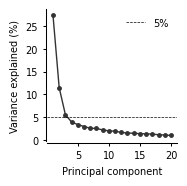

In [40]:
fig, ax = plt.subplots(figsize=(5 * cm, 5 * cm))
ax.plot(
    scree["pc"],
    100 * scree["explained_variance_ratio"],
    "o-",
    color="#333333",
    lw=1,
    ms=2.5,
)
ax.axhline(5.0, color="k", ls="--", lw=0.5, label="5%")
ax.set_xlabel("Principal component", **fontdict)
ax.set_ylabel("Variance explained (%)", **fontdict)
ax.set_xticks(list(range(5, int(scree["pc"].max()) + 1, 5)))
style_ax(ax, trim=False)
ax.legend(frameon=False, fontsize=fontsize)
fig.tight_layout()
save_svg(fig, IMG / "pca_variance.svg", close=False)
print("Wrote", IMG / "pca_variance.svg")

## Figure 1E — silhouette and Calinski–Harabasz vs *k*

Median over 500 random initialisations for k-means, k-medoids, and GMM. Ward is deterministic.


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/pc_cluster_metrics.svg


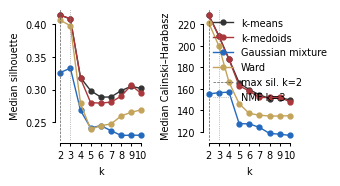

In [ ]:
def _plot_metric(ax, column, ylabel):
    for method, color in METHOD_COLORS.items():
        sub = metrics.loc[metrics["method"].eq(method)].sort_values("k")
        if sub.empty:
            continue
        ax.plot(
            sub["k"],
            sub[column],
            "o-",
            color=color,
            lw=1,
            ms=3.5,
            label=METHOD_LABELS[method],
        )
    ax.axvline(k_sil, color="0.35", ls="--", lw=0.5, label=f"max sil. k={k_sil}")
    ax.axvline(NMF_K, color="0.55", ls=":", lw=0.5, label=f"NMF k={NMF_K}")
    ax.set_xlabel("k", **fontdict)
    ax.set_ylabel(ylabel, **fontdict)
    ax.set_xticks(sorted(metrics["k"].unique()))
    style_ax(ax)


fig, axes = plt.subplots(1, 2, figsize=(8 * cm, 5 * cm))
_plot_metric(axes[0], "silhouette_median", "Median silhouette")
_plot_metric(axes[1], "calinski_median", "Median Calinski–Harabasz")
axes[1].legend(frameon=False, fontsize=fontsize, loc="best")
fig.tight_layout()
save_svg(fig, IMG / "pc_cluster_metrics.svg", close=False)
print("Wrote", IMG / "pc_cluster_metrics.svg")

## NMF rank metrics — justifying *k*=3

Same concat matrix as the canonical NMF fit. Primary: cophenetic correlation of the electrode-bootstrap consensus (the rule in `chosen_k.json`). Also shown: mean pairwise bootstrap ARI, cosine silhouette of NMF hard labels on `X`, and reconstruction error \(\|X-WH\|_F\).

Cophenetic / ARI peak at *k*=3. Cosine silhouette is slightly higher at *k*=2 and collapses at *k*≥4. Reconstruction always falls with *k*; the elbow is the kneedle point (maximum deviation from the chord joining the first and last *k*). These curves select the NMF rank; the PC-space panel above does not.


 k  cophenetic  mean_ari  silhouette_cosine  reconstruction_error
 2    0.998463  0.974957           0.336291              9.085913
 3    0.998703  0.980255           0.318636              8.348479
 4    0.988076  0.890054           0.153605              7.984807
 5    0.953993  0.690107           0.111489              7.740961
 6    0.965996  0.710678           0.097783              7.498561
chosen k=3  rule=max_cophenetic  near-ties=[2, 3, 4]
reconstruction drop:
  2→3: 0.737
  3→4: 0.364
  4→5: 0.244
  5→6: 0.242
kneedle elbow (recon): k=3


PosixPath('/hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/nmf_rank_k.svg')

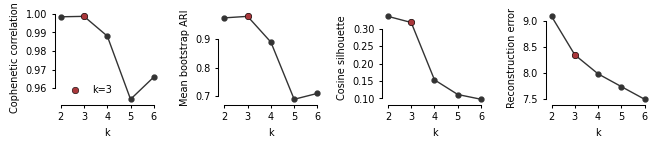

In [ ]:
import json

rank = pd.read_csv(RESULTS / "rank_selection_metrics.csv")
chosen = json.loads((RESULTS / "chosen_k.json").read_text(encoding="utf-8"))
k_nmf = int(chosen["k"])
ks = rank["k"].to_numpy(int)
err = rank["reconstruction_error"].to_numpy(float)


def kneedle_decreasing(k, y):
    """Elbow = max deviation below the chord from first to last k (kneedle)."""
    k = np.asarray(k, dtype=float)
    y = np.asarray(y, dtype=float)
    x = (k - k.min()) / (k.max() - k.min())
    yn = (y - y.min()) / (y.max() - y.min())
    chord = yn[0] + (yn[-1] - yn[0]) * x
    idx = int(np.argmax(chord - yn))
    return int(k[idx])


k_elbow = kneedle_decreasing(ks, err)
delta = -np.diff(err)
print(
    rank[
        ["k", "cophenetic", "mean_ari", "silhouette_cosine", "reconstruction_error"]
    ].to_string(index=False)
)
print(f"chosen k={k_nmf}  rule={chosen['rule']}  near-ties={chosen['near_tie_ks']}")
print("reconstruction drop:")
for k0, k1, d in zip(ks[:-1], ks[1:], delta):
    print(f"  {k0}→{k1}: {d:.3f}")
print(f"kneedle elbow (recon): k={k_elbow}")

panels = (
    ("cophenetic", "Cophenetic correlation"),
    ("mean_ari", "Mean bootstrap ARI"),
    ("silhouette_cosine", "Cosine silhouette"),
    ("reconstruction_error", "Reconstruction error"),
)
fig, axes = plt.subplots(1, 4, figsize=(20 * cm, 5 * cm), sharex=True)
for ax, (col, ylabel) in zip(axes, panels):
    ax.plot(rank["k"], rank[col], "o-", color="#333333", lw=1, ms=3.5, zorder=2)
    y_star = float(rank.loc[rank["k"].eq(k_nmf), col].iloc[0])
    ax.scatter(
        [k_nmf],
        [y_star],
        s=22,
        color=red,
        edgecolor="black",
        linewidth=0.4,
        zorder=3,
        label=f"k={k_nmf}",
    )
    ax.set_xlabel("k", **fontdict)
    ax.set_ylabel(ylabel, **fontdict)
    ax.set_xticks(sorted(ks.tolist()))
    style_ax(ax)
axes[0].legend(frameon=False, fontsize=fontsize, loc="best")
fig.tight_layout()
save_svg(fig, IMG / "nmf_rank_k.svg", close=False)

## Sanity check — k-means *k*=3, matched to NMF

PC1–PC2 scatter colored by k-means at NMF *k*=3 after Hungarian matching onto NMF names, with PC1 and PC2 marginal histograms on the corresponding axes.

Adjusted Rand index and the NMF × k-means table are printed below the figure.


ARI  NMF vs k-means k=3: 0.749
NMF × matched k-means k=3
kmeans_k3           sustain  motor  sensory
functional_cluster                         
sustain                  73      0        1
motor                    16    123        3
sensory                   1      0       38
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/waveform_pca_kmeans.svg


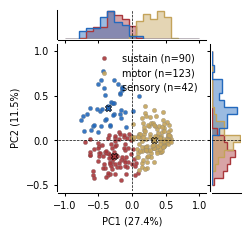

In [ ]:
from matplotlib.ticker import MultipleLocator
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

embed = scores[[f"PC{i}" for i in range(1, n_embed + 1)]].to_numpy(float)
nmf = scores["functional_cluster"].astype(str)
explained = np.asarray(meta["explained_variance_ratio"], dtype=float)
rng = int(meta["random_state"])

km3 = KMeans(n_clusters=NMF_K, n_init=50, random_state=rng).fit_predict(embed)
nmf_names = ordered_clusters(nmf)
conf = pd.crosstab(pd.Series(km3), nmf).reindex(columns=nmf_names, fill_value=0)
rows, cols = linear_sum_assignment(-conf.to_numpy(float))
km3_to_name = {int(conf.index[r]): nmf_names[c] for r, c in zip(rows, cols)}
km3_named = np.array([km3_to_name[int(v)] for v in km3])

print(f"ARI  NMF vs k-means k={NMF_K}: {adjusted_rand_score(nmf, km3):.3f}")
print("NMF × matched k-means k=3")
print(pd.crosstab(nmf, pd.Series(km3_named, name="kmeans_k3")).reindex(index=nmf_names, columns=nmf_names))

x = scores["PC1"].to_numpy(float)
y = scores["PC2"].to_numpy(float)
x_bins = np.linspace(np.floor(x.min() / 0.5) * 0.5, np.ceil(x.max() / 0.5) * 0.5, 20)
y_bins = np.linspace(np.floor(y.min() / 0.5) * 0.5, np.ceil(y.max() / 0.5) * 0.5, 20)

fig = plt.figure(figsize=(6 * cm, 6 * cm))
grid = fig.add_gridspec(
    2,
    2,
    width_ratios=(5.0, 1),
    height_ratios=(1, 5.0),
    wspace=0.06,
    hspace=0.06,
)
ax_histx = fig.add_subplot(grid[0, 0])
ax = fig.add_subplot(grid[1, 0], sharex=ax_histx)
ax_histy = fig.add_subplot(grid[1, 1], sharey=ax)

for cluster in nmf_names:
    mask = km3_named == cluster
    color = FUNCTION_COLORS.get(cluster, "0.4")
    ax.scatter(
        x[mask],
        y[mask],
        s=10,
        color=color,
        edgecolor="gray",
        linewidth=0.2,
        alpha=0.9,
        label=f"{cluster} (n={int(mask.sum())})",
    )
    ax.scatter(
        x[mask].mean(),
        y[mask].mean(),
        s=20,
        marker="X",
        color=color,
        edgecolor="black",
        linewidth=0.5,
        zorder=3,
    )
    ax_histx.hist(
        x[mask],
        bins=x_bins,
        density=True,
        histtype="stepfilled",
        color=color,
        alpha=0.45,
        linewidth=0,
    )
    ax_histx.hist(x[mask], bins=x_bins, density=True, histtype="step", color=color, linewidth=1)
    ax_histy.hist(
        y[mask],
        bins=y_bins,
        density=True,
        histtype="stepfilled",
        orientation="horizontal",
        color=color,
        alpha=0.45,
        linewidth=0,
    )
    ax_histy.hist(
        y[mask],
        bins=y_bins,
        density=True,
        histtype="step",
        orientation="horizontal",
        color=color,
        linewidth=1,
    )

ax.set_xlabel(f"PC1 ({100 * explained[0]:.1f}%)", **fontdict)
ax.set_ylabel(f"PC2 ({100 * explained[1]:.1f}%)", **fontdict)
ax.axhline(0.0, color="k", linestyle="--", linewidth=0.5)
ax.axvline(0.0, color="k", linestyle="--", linewidth=0.5)
ax_histx.axvline(0.0, color="k", linestyle="--", linewidth=0.5)
ax_histy.axhline(0.0, color="k", linestyle="--", linewidth=0.5)
style_ax(ax, trim=False)
style_ax(ax_histx, trim=False)
style_ax(ax_histy, trim=False)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax_histx.tick_params(labelbottom=False, labelleft=False, left=False)
ax_histx.set_yticks([])
ax_histy.tick_params(labelleft=False, labelbottom=False, bottom=False)
ax_histy.set_xticks([])
ax.legend(frameon=False, fontsize=fontsize, loc="best")
save_svg(fig, IMG / "waveform_pca_kmeans.svg", close=False)
print("Wrote", IMG / "waveform_pca_kmeans.svg")